# 🧠 Liver Tumor Segmentation - Clean Pipeline Notebook

## 📦 Imports

In [1]:

import os
import cv2
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.model_selection import train_test_split


## 📁 Paths

In [2]:

BASE_PATH =r"C:\Users\prana\OneDrive\Desktop\projects\Medical image\archive\dataset_6\dataset_6"
CSV_PATH =r"C:\Users\prana\OneDrive\Desktop\projects\Medical image\archive\balanced_11200.csv"


## 📊 Load Dataset

In [3]:

df = pd.read_csv(CSV_PATH)
data = list(zip(df["image"], df["mask"]))

train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)
print(len(train_data), len(val_data))


8960 2240


## 🧱 Dataset Class

In [4]:

class LiverDataset(Dataset):
    def __init__(self, data, base_path):
        self.data = data
        self.base_path = base_path

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, mask_path = self.data[idx]

        img = cv2.imread(os.path.join(self.base_path, img_path), 0)
        mask = cv2.imread(os.path.join(self.base_path, mask_path), 0)

        img = cv2.resize(img, (128,128)) / 255.0
        mask = cv2.resize(mask, (128,128))
        mask = (mask > 0).astype("float32")

        img = torch.tensor(img).unsqueeze(0).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask


## 🚀 DataLoader

In [5]:

train_loader = DataLoader(LiverDataset(train_data, BASE_PATH), batch_size=8, shuffle=True)
val_loader   = DataLoader(LiverDataset(val_data, BASE_PATH), batch_size=8)


## 🧠 Model

In [6]:

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(128, 256)

        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv1 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool1(x1))
        x3 = self.bridge(self.pool2(x2))

        x = self.up1(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.conv1(x)

        x = self.up2(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv2(x)

        return self.out(x)


## 🔥 Training

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0]).to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

for epoch in range(20):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), "UNet_model.pth")


## 📏 Dice Score

In [ ]:

def dice_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.2).float()

    smooth = 1e-5
    intersection = (pred * target).sum()

    return (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)


Non-tumor images

In [7]:
import cv2
import os

non_tumor_images = []

for img_path, mask_path in data:
    mask_full = os.path.join(BASE_PATH, mask_path)

    mask = cv2.imread(mask_full, 0)

    if mask is None:
        continue

    # if mask has NO white pixels → non-tumor
    if (mask > 0).sum() == 0:
        non_tumor_images.append((img_path, mask_path))

print("Total non-tumor images:", len(non_tumor_images))

for i in range(5):
    print(non_tumor_images[i])
    

Total non-tumor images: 5600
('volume-115_256.png', 'segmentation-115_lesionmask_256.png')
('volume-18_374.png', 'segmentation-18_lesionmask_374.png')
('volume-109_716.png', 'segmentation-109_lesionmask_716.png')
('volume-102_620.png', 'segmentation-102_lesionmask_620.png')
('volume-89_479.png', 'segmentation-89_lesionmask_479.png')


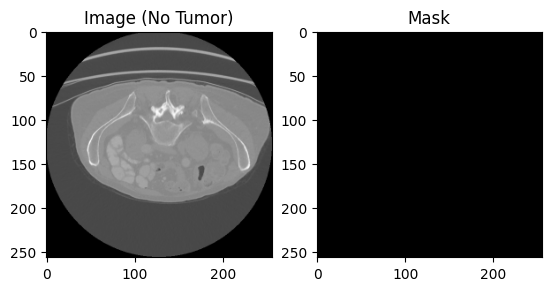

In [8]:
img_path, mask_path = non_tumor_images[0]

img = cv2.imread(os.path.join(BASE_PATH, img_path), 0)
mask = cv2.imread(os.path.join(BASE_PATH, mask_path), 0)

plt.subplot(1,2,1)
plt.title("Image (No Tumor)")
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask, cmap='gray')

plt.show()

## 🔍 Prediction + Visualization

In [9]:

def predict_image(image_path):
    img = cv2.imread(image_path, 0)
    img = cv2.resize(img, (128,128))

    original = img.copy()
    img = img / 255.0

    img_tensor = torch.tensor(img).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        output = model(img_tensor)

    prob = torch.sigmoid(output).cpu().squeeze().numpy()
    pred = (prob > 0.2).astype("float32")

    return original, prob, pred

img_path = os.path.join(BASE_PATH, val_data[0][0])
original, prob, pred = predict_image(img_path)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Input"); plt.imshow(original, cmap='gray')
plt.subplot(1,3,2); plt.title("Prob"); plt.imshow(prob, cmap='hot')
plt.subplot(1,3,3); plt.title("Pred"); plt.imshow(pred, cmap='gray')
plt.show()


NameError: name 'device' is not defined